In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [5]:
print("hi")

hi


In [30]:
class discount_state(TypedDict):
    item_name:str
    price:float
    product_type:str
    discount:float
    final_price:float
    summary:str



In [31]:
graph=StateGraph(discount_state)

In [32]:
def check_condition(state:discount_state)-> Literal['cheap_discount','regular_discount','expensive_discount']:
    type=state['product_type']
    if type=='cheap':
        return 'cheap_discount'
    elif type=="regular":
        return 'regular_discount'
    else:
        return "expensive_discount"


def item_classification(state:discount_state):
    price=state['price']
    if price<=100:
        type='cheap'
    elif price<=10000:
        type='regular'
    else:
        type="expensive"

    return {'product_type':type}

def cheap_discount(state:discount_state):
    price=state['price']
    discount=0.05*100
    final_price=price*0.95
    return {f'final_price':final_price,'discount':discount}

def regular_discount(state:discount_state):
    price=state['price']
    discount=0.1*100
    final_price=price*0.90
    return {f'final_price':final_price,'discount':discount}

def expensive_discount(state:discount_state):
    price=state['price']
    discount=0.2*100
    final_price=price*0.8
    return {f'final_price':final_price,'discount':discount}

def summary(state:discount_state):
    item_name=state['item_name']
    price=state['price']
    discount=state['discount']
    final_price=state['final_price']
    summary=f"Item: {item_name}, Original Price: {price}, Discount: {discount}, Final Price: {final_price}"
    return {'summary':summary}


In [33]:
# ['cheap','regular','expensive']

# defining the graph nodes and edges
graph.add_node('item_classification',item_classification)
graph.add_node('cheap_discount',cheap_discount)
graph.add_node('regular_discount',regular_discount)
graph.add_node('expensive_discount',expensive_discount)
graph.add_node('summary',summary)

graph.add_edge(START,'item_classification')

graph.add_conditional_edges('item_classification',check_condition)
graph.add_edge(['cheap_discount','regular_discount','expensive_discount'],'summary')
graph.add_edge('summary',END)

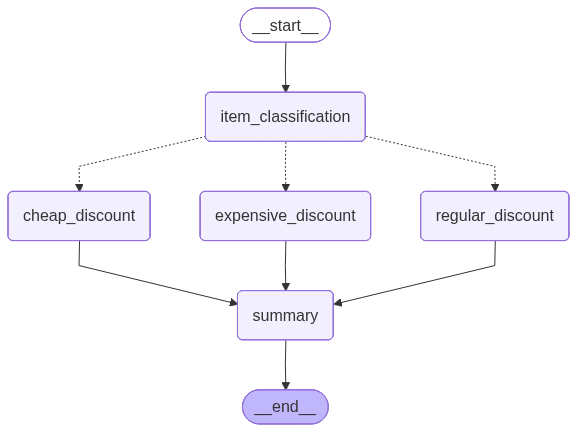

In [34]:
workflow=graph.compile()
workflow

In [35]:
initial_state={'item_name':'Laptop','price':9999.0}

output=workflow.invoke(initial_state)
output

{'item_name': 'Laptop',
 'price': 9999.0,
 'product_type': 'regular',
 'discount': 10.0,
 'final_price': 8999.1}